# EDA 01 — Qualidade dos dados e granularidade viável

**Projeto:** canavis — benchmarking regional da cana-de-açúcar na Paraíba  
**Usuário final:** Ricardo, gerente agrícola de usina (decisões estruturais de longo prazo)

Antes de validar ou minerar qualquer indicador, é preciso saber em que granularidade os dados são confiáveis. A Produção Agrícola Municipal suprime valores de municípios pequenos, e isso condiciona tudo: não adianta prometer *tendência municipal* se metade dos municípios tem série cheia de buracos.

Este notebook responde a três perguntas:

1. Quanta informação a PAM suprime, e onde?
2. Em que nível territorial (município, microrregião, UF) a série de 21 anos é sólida?
3. Qual granularidade cada tipo de análise pode usar sem enganar o Ricardo?

As funções de diagnóstico vêm do pacote (`canavis.validation`), não são código solto: o que se prova aqui é reproduzível e testável.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from canavis import storage
from canavis.config import load_settings
from canavis.validation import taxa_ausentes, cobertura_por_periodo, completude_serie

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RENDIMENTO = "Rendimento médio da produção"

interim = load_settings().paths.interim
pam = storage.read(interim, "ibge_pam")
pam["extracao"].value_counts()

extracao
serie_municipios_pb       8989
serie_ufs_brasil          2835
serie_microrregioes_pb    1535
Name: count, dtype: int64

## 1. Quanto a PAM suprime, e em que nível

A supressão aparece como valor ausente após a limpeza. Medimos a taxa de ausentes do rendimento em cada nível territorial. Quanto mais fina a granularidade, maior a supressão esperada.

In [2]:
# Recompoe a base com ausentes visiveis: parte do bronze para nao perder o que foi suprimido
bronze = storage.read(load_settings().paths.raw, "ibge_pam")
rend_bruto = bronze[bronze["variavel"] == RENDIMENTO].copy()
rend_bruto["valor_num"] = pd.to_numeric(
    rend_bruto["valor"].astype(str).str.replace(".", "", regex=False),
    errors="coerce",
)

ausentes = taxa_ausentes(rend_bruto, valor="valor_num", grupo="extracao")
ausentes

,extracao,total,ausentes,taxa_ausentes
1,serie_municipios_pb,4683,2886,0.616272
0,serie_microrregioes_pb,483,176,0.364389
2,serie_ufs_brasil,567,0,0.000000


A leitura é direta: o nível municipal concentra a supressão, o de microrregião a reduz e o de UF praticamente não a tem. Isso é esperado — o IBGE protege o sigilo de produtores onde há poucos, e agregar dilui esse efeito.

## 2. A série de 21 anos é sólida em cada nível?

Taxa de ausentes média esconde o que importa para análise de longo prazo: uma coisa é faltar um ano aqui e ali, outra é o município só ter dado em três dos vinte e um anos. Medimos a **completude da série** — a fração de anos com dado — por unidade territorial.

In [3]:
def resumo_completude(extracao):
    sub = pam[(pam["extracao"] == extracao) & (pam["variavel"] == RENDIMENTO)]
    comp = completude_serie(sub, valor="valor", periodo="periodo", unidade="local")
    return comp


completude = {
    "município": resumo_completude("serie_municipios_pb"),
    "microrregião": resumo_completude("serie_microrregioes_pb"),
    "UF": resumo_completude("serie_ufs_brasil"),
}

for nivel, comp in completude.items():
    completos = int((comp["completude"] == 1.0).sum())
    print(
        f"{nivel:>13}: {len(comp):>3} unidades | "
        f"série completa: {completos:>3} | "
        f"completude média: {comp['completude'].mean():.1%}"
    )

    município: 120 unidades | série completa:  58 | completude média: 71.3%
 microrregião:  17 unidades | série completa:  13 | completude média: 86.0%
           UF:  27 unidades | série completa:  27 | completude média: 100.0%


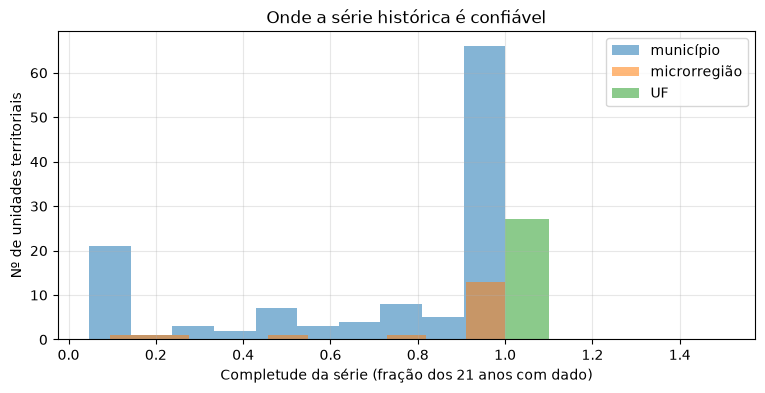

In [4]:
fig, ax = plt.subplots()
for nivel, comp in completude.items():
    ax.hist(comp["completude"], bins=10, alpha=0.55, label=nivel)
ax.set_xlabel("Completude da série (fração dos 21 anos com dado)")
ax.set_ylabel("Nº de unidades territoriais")
ax.set_title("Onde a série histórica é confiável")
ax.legend()
plt.show()

O histograma separa os níveis com clareza. No município, boa parte das unidades fica com completude parcial — a série tem furos. Na microrregião, a massa se concentra perto de 100%. Para qualquer indicador que dependa da série inteira (tendência, volatilidade, resiliência), a microrregião é o piso seguro.

## 3. A cobertura melhora ou piora ao longo do tempo?

Se a supressão municipal aumentou nos últimos anos, mesmo os municípios "bons" ficam frágeis no fim da série, que é o período mais relevante para decisão. Contamos quantos municípios têm dado em cada ano.

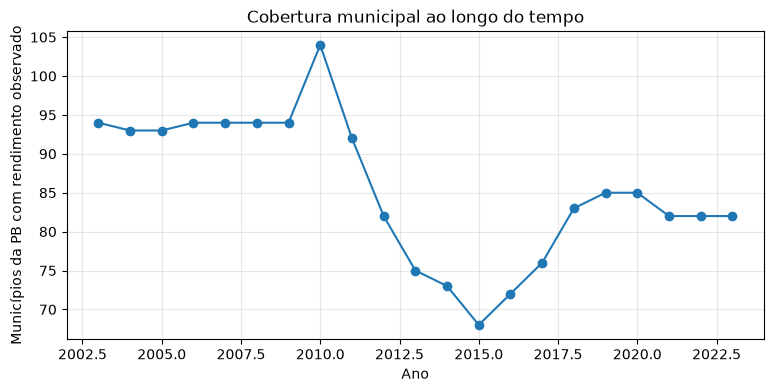

,periodo,unidades_com_dado
15,2018,83
16,2019,85
17,2020,85
18,2021,82
19,2022,82
20,2023,82


In [5]:
mun = pam[(pam["extracao"] == "serie_municipios_pb") & (pam["variavel"] == RENDIMENTO)]
cobertura = cobertura_por_periodo(mun, valor="valor", periodo="periodo", unidade="local")

fig, ax = plt.subplots()
ax.plot(cobertura["periodo"], cobertura["unidades_com_dado"], marker="o")
ax.set_xlabel("Ano")
ax.set_ylabel("Municípios da PB com rendimento observado")
ax.set_title("Cobertura municipal ao longo do tempo")
plt.show()
cobertura.tail(6)

## Veredito de granularidade

| Tipo de análise | Granularidade recomendada | Motivo |
|-----------------|---------------------------|--------|
| Retrato de um ano (ranking, participação) | Município | Um corte anual tolera ausências; municípios sem dado ficam marcados como *sem informação*. |
| Série de longo prazo (tendência, volatilidade, resiliência) | Microrregião | Só a microrregião sustenta os 21 anos com completude alta o bastante para não enganar. |
| Benchmarking nacional | UF | Série praticamente sem supressão; comparação entre estados é segura. |

Este veredito alimenta o ADR de granularidade e condiciona a fase seguinte: os indicadores de tendência que vamos minerar nascem no nível de microrregião, não de município. Descobrir isso agora é falhar barato — evita construir na Etapa 2 um ranking municipal de tendência que seria estatisticamente indefensável.